# <a id='toc1_'></a>[<span style="color:yellow;">Lucas-Kanade Optical Flow](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [<span style="color:yellow;">Lucas-Kanade Optical Flow](#toc1_)    
- [Step 1: Load Necessary Libraries](#toc2_)    
- [Step 2: Load and preprocess video](#toc3_)    
- [Step 3: Corner/Edge/Flat](#toc4_)    
  - [Step 3.1: Compute Intensity Gradients $(dx, dy)$](#toc4_1_)    
  - [Step 3.2: Calculate Structure Tensor Components $(I_{xx}, I_{xy}, I_{yy})$](#toc4_2_)    
  - [Step 3.3: Smooth Components with Gaussian Blur](#toc4_3_)    
  - [Step 3.4: Compute Eigenvalues of the Structure Tensor](#toc4_4_)    
  - [Step 3.5: Classify Pixels](#toc4_5_)    
  - [Step 3.6: Visualize Classification](#toc4_6_)    
- [Step 4: Detect initial feature points](#toc5_)    
  - [Step 4.1: Understand Shi-Tomasi Selection Criterion](#toc5_1_)    
  - [Step 4.2: Configure Detector Parameters](#toc5_2_)    
  - [Step 4.3: Run the Shi-Tomasi Detector on the First Frame](#toc5_3_)    
  - [Step 4.4: Visualize and Validate Detected Features](#toc5_4_)    
- [Step 5: Set up Lucas-Kanade parameters](#toc6_)    
  - [Step 5.1: Mathematical Foundations & Core Assumptions of Lucas-Kanade](#toc6_1_)    
    - [Assumption 1: Brightness Constancy](#toc6_1_1_)    
    - [Assumption 2: Small Motion](#toc6_1_2_)    
  - [Step 5.2: Define Key Lucas-Kanade Parameters](#toc6_2_)    
- [Step 6: Perform optical flow tracking](#toc7_)    
  - [Step 6.1: Initialize Tracking Variables](#toc7_1_)    
  - [Step 6.2: Prepare the First Frame for Tracking](#toc7_2_)    
  - [Step 6.3: Iterate Over Consecutive Frames (Frame-by-Frame Tracking)](#toc7_3_)    
  - [Step 6.7: Visualize Sample Tracked Frames (Validation)](#toc7_4_)    
- [Step 7: Create and Display Animation](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Load Necessary Libraries](#toc0_)

In [33]:
%matplotlib inline

In [34]:
import cv2          # OpenCV library for computer vision tasks
import matplotlib   # Plotting library
import numpy as np  # Numerical operations library
import matplotlib.pyplot as plt  # Matplotlib's plotting interface
from matplotlib import animation  # For creating animations
from skimage import data  # Sample image data
from IPython.display import HTML, display  # For displaying HTML/animations in Jupyter

# <a id='toc3_'></a>[Step 2: Load and preprocess video](#toc0_)

In [35]:
# Load a sample grayscale image (camera man) and create a video sequence
# We'll simulate motion by shifting the image horizontally across frames
image = data.camera()  # 512x512 grayscale image from scikit-image
video = []
for i in range(20):  # Create 20 frames with increasing horizontal shift
    # Roll (shift) the image horizontally by i*3 pixels
    # Positive values shift right, negative values shift left
    shifted = np.roll(image, i*3, axis=1)  # axis=1 means horizontal shift
    video.append(shifted)

In [36]:
# Stack frames into a 3D array with shape (num_frames, height, width)
video = np.stack(video, axis=0)

In [37]:
# Get video dimensions
num_frames, h, w = video.shape
print(f"Video dimensions: {video.shape} \n(frames: {num_frames}, height: {h}, width: {w})")

Video dimensions: (20, 512, 512) 
(frames: 20, height: 512, width: 512)


In [38]:
# Resize video to maximum 128x128 for better performance
max_size = 128
# Calculate scaling factor to maintain aspect ratio
scale = min(max_size/h, max_size/w)
new_h, new_w = int(h*scale), int(w*scale)
print(f"Resizing video from {w}x{h} to {new_w}x{new_h} (scale factor: {scale:.2f})")

Resizing video from 512x512 to 128x128 (scale factor: 0.25)


In [39]:
# Prepare lists to store processed frames
frames = []          # Will hold 3-channel (BGR) frames for drawing
gray_frames = []     # Will hold grayscale frames for optical flow calculations

In [40]:
# Process each frame
for i in range(num_frames):
    # Resize frame to new dimensions
    frame = cv2.resize(video[i], (new_w, new_h))
    # Convert grayscale to BGR (3-channel) for drawing colored features/tracks
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
    frames.append(frame_bgr)
    # Convert back to grayscale (consistent with original for processing)
    gray_frames.append(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY))

In [41]:
print(f"Video information: {num_frames} frames, \nresized to {new_w}x{new_h}")

Video information: 20 frames, 
resized to 128x128


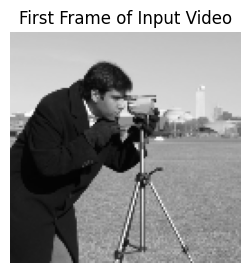

In [42]:
# Display first frame to verify
plt.figure(figsize=(4, 3))
# Convert BGR to RGB for proper color display in matplotlib
plt.imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB))
plt.title("First Frame of Input Video")
plt.axis('off')  # Turn off axis labels
plt.show()

# <a id='toc4_'></a>[Step 3: Corner/Edge/Flat](#toc0_)

*A <span style="color: #2E86AB;">corner</span> is a pixel where the image intensity changes significantly in two perpendicular directions*—unlike <span style="color: #A23B72;">edges</span> (where intensity changes in only one direction) or <span style="color: #F18F01;">flat regions</span> (where there is little change).

## <a id='toc4_1_'></a>[Step 3.1: Compute Intensity Gradients $(dx, dy)$](#toc0_)

In [43]:
# Take the first grayscale frame
gray_frame = gray_frames[0]  # Reuse the preprocessed frame
h, w = gray_frame.shape

In [44]:
# Compute intensity gradients (dx = horizontal, dy = vertical)
# Use Sobel operator (common for gradient calculation)
dx = cv2.Sobel(gray_frame, cv2.CV_64F, 1, 0, ksize=3)  # 1=dx, 0=dy
dy = cv2.Sobel(gray_frame, cv2.CV_64F, 0, 1, ksize=3)  # 0=dx, 1=dy

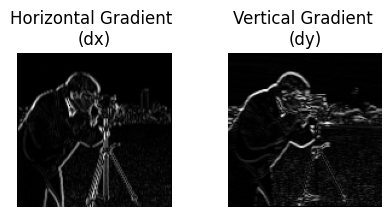

In [45]:
# To verify gradients, you can plot dx and dy
# (dark regions = small gradients, bright regions = large gradients):
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2))
ax1.imshow(np.abs(dx), cmap='gray')  # Absolute value to show magnitude
ax1.set_title("Horizontal Gradient \n(dx)")
ax1.axis('off')
ax2.imshow(np.abs(dy), cmap='gray')
ax2.set_title("Vertical Gradient \n(dy)")
ax2.axis('off')
plt.show()

## <a id='toc4_2_'></a>[Step 3.2: Calculate Structure Tensor Components $(I_{xx}, I_{xy}, I_{yy})$](#toc0_)

The structure tensor $M$ for a pixel is a $2x2$ matrix that summarizes gradient information in a local neighborhood. <br>
It is defined as:
$$M = \begin{bmatrix} I_{xx} & I_{xy} \\ I_{xy} & I_{yy} \end{bmatrix}$$
Where:
* $I_{xx} = dx^2$: Squared horizontal gradient (emphasizes strong horizontal changes)
* $I_{yy} = dy^2$: Squared vertical gradient (emphasizes strong vertical changes)
* $I_{xy} = dx\times dy$: Cross-correlation of horizontal and vertical gradients (captures diagonal changes)

In [46]:
# Compute the three components of the structure tensor
Ixx = dx ** 2       # Squared horizontal gradient
Ixy = dx * dy       # Cross product of dx and dy
Iyy = dy ** 2       # Squared vertical gradient

## <a id='toc4_3_'></a>[Step 3.3: Smooth Components with Gaussian Blur](#toc0_)

In [47]:
# Gaussian blur parameters: balance noise reduction and detail preservation
kernel_size = 5    # 5x5 neighborhood (standard for local smoothing)
sigma = 1          # Gaussian spread (small sigma = less blur, preserves details)

# Apply Gaussian blur to each structure tensor component
Ixx = cv2.GaussianBlur(Ixx, (kernel_size, kernel_size), sigma)
Ixy = cv2.GaussianBlur(Ixy, (kernel_size, kernel_size), sigma)
Iyy = cv2.GaussianBlur(Iyy, (kernel_size, kernel_size), sigma)

## <a id='toc4_4_'></a>[Step 3.4: Compute Eigenvalues of the Structure Tensor](#toc0_)

The structure tensor’s eigenvalues ($\lambda_1, \lambda_2$, sorted such that $\lambda_1 \geq \lambda_2$) <br>
reveal the direction and magnitude of the strongest intensity changes around a pixel.

In [48]:
# Initialize array to store eigenvalues (shape: [height, width, 2], where index 0=λ1, 1=λ2)
eigenvalues = np.zeros((h, w, 2), dtype=np.float64)

# Compute eigenvalues for every pixel's structure tensor
for y in range(h):  # Iterate over each row (vertical axis)
    for x in range(w):  # Iterate over each column (horizontal axis)
        # Extract the 2x2 structure tensor for pixel (x, y)
        M = np.array([
            [Ixx[y, x], Ixy[y, x]], 
            [Ixy[y, x], Iyy[y, x]]
        ])
        # Compute eigenvalues of M (np.linalg.eig returns unsorted values)
        eigvals, _ = np.linalg.eig(M)
        # Sort eigenvalues: λ1 (larger) → index 0, λ2 (smaller) → index 1
        eigenvalues[y, x, 0] = max(eigvals)
        eigenvalues[y, x, 1] = min(eigvals)

## <a id='toc4_5_'></a>[Step 3.5: Classify Pixels](#toc0_)

In [49]:
# Threshold: Tuned for the "camera man" image (adjust based on your input)
# Higher threshold = stricter classification (fewer corners/edges detected)
threshold = 1000  

# Create binary masks (True = pixel belongs to the class)
corner_mask = (eigenvalues[..., 0] > threshold) & (eigenvalues[..., 1] > threshold)  # Both λ large
edge_mask = (eigenvalues[..., 0] > threshold) & (eigenvalues[..., 1] < threshold/2)   # One λ large, one small
flat_mask = (eigenvalues[..., 0] < threshold/2) & (eigenvalues[..., 1] < threshold/2) # Both λ small

## <a id='toc4_6_'></a>[Step 3.6: Visualize Classification](#toc0_)

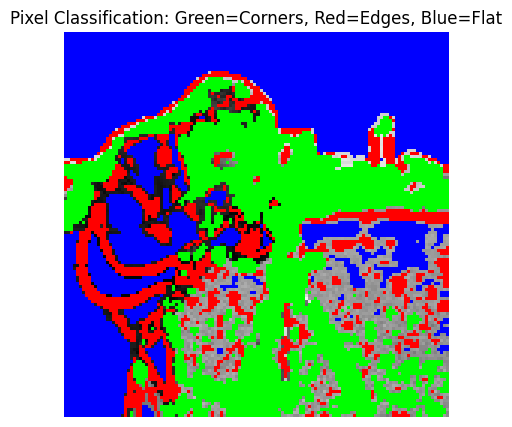

In [50]:
# Convert grayscale frame to RGB (3-channel) for color overlay
rgb_frame = cv2.cvtColor(gray_frame, cv2.COLOR_GRAY2RGB)

# Apply color coding to masks
rgb_frame[corner_mask] = [0, 255, 0]    # Green: Corners
rgb_frame[edge_mask] = [255, 0, 0]      # Red: Edges
rgb_frame[flat_mask] = [0, 0, 255]      # Blue: Flat Regions

# Display the result
plt.figure(figsize=(6, 5))
plt.imshow(rgb_frame)
plt.title("Pixel Classification: Green=Corners, Red=Edges, Blue=Flat")
plt.axis('off')
plt.show()

In [51]:
# Print statistics to quantify results
total_corners = np.sum(corner_mask)
total_edges = np.sum(edge_mask)
total_flat = np.sum(flat_mask)

In [52]:
print(f"Pixel Classification Stats:")
print(f"- Corners (both λ large): {total_corners} pixels")
print(f"- Edges (one λ large): {total_edges} pixels")
print(f"- Flat regions (both λ small): {total_flat} pixels")

Pixel Classification Stats:
- Corners (both λ large): 4704 pixels
- Edges (one λ large): 2300 pixels
- Flat regions (both λ small): 6175 pixels


# <a id='toc5_'></a>[Step 4: Detect initial feature points](#toc0_)

* The `Shi-Tomasi Corner Detector` is a classic `computer vision` algorithm designed to identify corner features in images. 

* Proposed by Jianbo Shi and Carlo Tomasi in their 1994 paper "Good Features to Track", it is an optimized and improved version of the earlier `Harris Corner Detector`

* —and is widely used for tasks like `object tracking`, `image stitching`, and `3D reconstruction` due to its better performance in selecting "<span style='color:red;'>stable, distinct, reliable, and trackable corners.</span>"

## <a id='toc5_1_'></a>[Step 4.1: Understand Shi-Tomasi Selection Criterion](#toc0_)

The `Shi-Tomasi detector` improves upon the `Harris corner detector` by using a more robust criterion to select corners. 

For a pixel with structure tensor eigenvalues $\lambda_1 \geq \lambda_2$:
- Shi-Tomasi score: $\min(\lambda_1, \lambda_2)$
- A pixel is considered a "good feature" if this score exceeds a threshold.

This ensures we select corners where both eigenvalues are large (stable, trackable features), unlike edges (one large eigenvalue) or flat regions (both small).

## <a id='toc5_2_'></a>[Step 4.2: Configure Detector Parameters](#toc0_)
The `Shi-Tomasi algorithm` requires parameters to control the quality, quantity, and spacing of detected features. These parameters balance between:

* Detecting enough features for reliable tracking
* Ensuring features are spatially distributed (not clustered)
* Filtering out low-quality features (e.g., noisy edges)

In [53]:
# Parameters for Shi-Tomasi corner detection
feature_params = dict(
    maxCorners=200,       # Maximum number of features to detect (prevents overcrowding)
    qualityLevel=0.1,     # Minimum quality threshold (0-1): only keep features with score > (qualityLevel × best_score)
    minDistance=5,        # Minimum distance (pixels) between detected features (avoids clustering)
    blockSize=7           # Size of the neighborhood used to compute the structure tensor
)

## <a id='toc5_3_'></a>[Step 4.3: Run the Shi-Tomasi Detector on the First Frame](#toc0_)
We apply the detector to the first frame of the video to select initial feature points. These points will be tracked through subsequent frames using optical flow.

In [54]:
# Detect features in the first grayscale frame
# goodFeaturesToTrack returns corners as a numpy array of shape (N, 1, 2)
p0 = cv2.goodFeaturesToTrack(
    image=gray_frames[0],  # Input grayscale frame (from Step 2)
    mask=None,             # Optional mask to restrict detection to a region (None = detect everywhere)
    **feature_params       # Apply our configured parameters
)

# Convert to float32 for compatibility with OpenCV's optical flow functions
p0 = p0.astype(np.float32)

## <a id='toc5_4_'></a>[Step 4.4: Visualize and Validate Detected Features](#toc0_)
To ensure the detector worked correctly, we overlay the detected features on the first frame and check:

- Features are corners (not edges or flat regions)
- Features are well-distributed across the frame
- Enough features were detected (but not too many)

Detected 43 initial feature points (out of maximum 200)


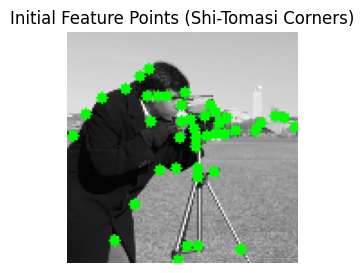

In [55]:
# Print statistics about detected features
print(f"Detected {len(p0)} initial feature points (out of maximum {feature_params['maxCorners']})")

# Create a copy of the first frame to draw features on
frame_with_features = frames[0].copy()

# Draw each feature as a green circle
for p in p0:
    x, y = p.ravel()  # Flatten (1,2) coordinates to (x,y)
    cv2.circle(
        img=frame_with_features,
        center=(int(x), int(y)),  # Convert to integers for pixel coordinates
        radius=3,                 # Circle size (pixels)
        color=(0, 255, 0),        # Green color (BGR format)
        thickness=-1              # -1 = filled circle
    )

# Display the result
plt.figure(figsize=(4, 3))
plt.imshow(cv2.cvtColor(frame_with_features, cv2.COLOR_BGR2RGB))  # Convert BGR→RGB for matplotlib
plt.title("Initial Feature Points (Shi-Tomasi Corners)")
plt.axis('off')  # Hide axes for clarity
plt.show()

# <a id='toc6_'></a>[Step 5: Set up Lucas-Kanade parameters](#toc0_)

The Lucas-Kanade (LK) algorithm estimates the motion of feature points between consecutive frames by solving a system of linear equations (derived from the brightness constancy and spatial coherence assumptions). 

To optimize tracking accuracy, speed, and robustness, we carefully configure its core parameters. 

## <a id='toc6_1_'></a>[Step 5.1: Mathematical Foundations & Core Assumptions of Lucas-Kanade](#toc0_)

The `Lucas-Kanade algorithm` estimates the motion vector $(u, v)$ of a feature point between two consecutive frames. 

This is derived from two critical assumptions, expressed mathematically below:

### <a id='toc6_1_1_'></a>[Assumption 1: Brightness Constancy](#toc0_)
A feature point’s intensity remains unchanged as it moves between frames. 

For a pixel at position $(x, y)$ in the first frame and $(x+u, y+v)$ in the next frame: 
$$I(x + u, y + v, t + \Delta t) = I(x, y, t)$$
Where:

- $I(x, y, t)$ = intensity at $(x, y)$ in frame $t$
- $I(x + u, y + v, t + \Delta t)$ = intensity at the new position $(x+u, y+v)$ in frame $t + \Delta t$
- $(u, v)$ = motion vector (displacement between frames)

### <a id='toc6_1_2_'></a>[Assumption 2: Small Motion](#toc0_)
The displacement $(u, v)$ is small enough to approximate the intensity function using a first-order Taylor expansion:
$$I(x + u, y + v, t + \Delta t) \approx I(x, y, t) + u \cdot I_x + v \cdot I_y + \Delta t \cdot I_t,$$
where:

- $I_x = \frac{\partial I}{\partial x}$ (horizontal intensity gradient, computed in Step 3.1)

- $I_y = \frac{\partial I}{\partial y}$ (vertical intensity gradient, computed in Step 3.1)

- $I_t = \frac{\partial I}{\partial t}$ (temporal intensity change between frames)

## <a id='toc6_2_'></a>[Step 5.2: Define Key Lucas-Kanade Parameters](#toc0_)
The LK algorithm (implemented in OpenCV’s `calcOpticalFlowPyrLK`) relies on 3 critical parameter groups: `search window size`, `pyramid levels`, and `termination criteria`. 

We define these in a dictionary for clarity and reusability.

In [56]:
# Parameters for Lucas-Kanade optical flow (Pyramid LK variant)
lk_params = dict(
    winSize=(15, 15),  # Size of the local search window for spatial coherence
    maxLevel=2,        # Number of pyramid levels for multi-scale tracking
    # Termination criteria: stop iteration when convergence is reached
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

In [57]:
# Print parameters to document the setup
print(f"Lucas-Kanade Parameter Summary:")
print(f"- Search Window Size: {lk_params['winSize']} → Balances spatial coherence and speed.")
print(f"- Max Pyramid Level: {lk_params['maxLevel']} → Handles {3*num_frames}px total motion (simulated shift).")
print(f"- Termination Criteria: Iterate up to {lk_params['criteria'][1]} times, or stop if error < {lk_params['criteria'][2]}.")

Lucas-Kanade Parameter Summary:
- Search Window Size: (15, 15) → Balances spatial coherence and speed.
- Max Pyramid Level: 2 → Handles 60px total motion (simulated shift).
- Termination Criteria: Iterate up to 10 times, or stop if error < 0.03.


# <a id='toc7_'></a>[Step 6: Perform optical flow tracking](#toc0_)

## <a id='toc7_1_'></a>[Step 6.1: Initialize Tracking Variables](#toc0_)
Before processing frames, we set up variables to store tracked data, maintain state between frames, and prepare for visualization. This ensures consistency and avoids reinitializing objects in each iteration.

In [58]:
# 1. Store frames with drawn tracks (for final animation/visualization)
tracked_frames = []  

# 2. Create a black mask to draw motion tracks (same size as input frames)
#    Tracks are drawn on this mask and overlaid on frames later
mask = np.zeros_like(frames[0])  

# 3. Initialize "previous" feature points (start with Step 4's detected corners)
p_prev = p0  # Shape: (N, 1, 2) → N points, each with (x,y) coordinates

# 4. Initialize "previous" grayscale frame (LK uses grayscale for intensity calculations)
gray_prev = gray_frames[0]  

## <a id='toc7_2_'></a>[Step 6.2: Prepare the First Frame for Tracking](#toc0_)
The first frame has no prior motion to compare against, so we add it to the tracked_frames list with only the initial feature points (from Step 4) drawn. This establishes a baseline for the tracking sequence.

In [59]:
# Create a copy of the first frame to avoid modifying the original
first_frame = frames[0].copy()

# Draw initial feature points (green filled circles) on the first frame
for p in p_prev:
    x, y = p.ravel()  # Flatten (1,2) coordinates to (x,y) for drawing
    cv2.circle(
        img=first_frame,
        center=(int(x), int(y)),  # Convert to integer (pixels are discrete)
        radius=5,                 # Circle size (visible but not overwhelming)
        color=(0, 255, 0),        # Green (BGR format) → matches Step 4's feature color
        thickness=-1              # -1 = filled circle (easier to see)
    )

# Add the first frame to the tracked_frames list
tracked_frames.append(first_frame)

## <a id='toc7_3_'></a>[Step 6.3: Iterate Over Consecutive Frames (Frame-by-Frame Tracking)](#toc0_)
We loop through all remaining frames (from frame 1 to frame num_frames-1), using cv2.`calcOpticalFlowPyrLK` (Pyramid Lucas-Kanade) to estimate feature motion between the previous frame and current frame.

In [60]:
# Loop through frames 1 to num_frames-1 (skip frame 0, already processed)
for i in range(1, num_frames):
    # 1. Get the current grayscale frame (LK requires grayscale input)
    gray_curr = gray_frames[i]  
    
    # 2. Run Lucas-Kanade optical flow to estimate current feature positions
    # Inputs: previous frame (gray_prev), current frame (gray_curr), previous points (p_prev)
    # Outputs:
    # - p_curr: Estimated current positions of features (shape: (N, 1, 2))
    # - status: Binary array (1 = feature tracked successfully, 0 = feature lost)
    # - err: Error of the motion estimation (higher = less reliable)
    p_curr, status, err = cv2.calcOpticalFlowPyrLK(
        prevImg=gray_prev,
        nextImg=gray_curr,
        prevPts=p_prev,
        nextPts=None,  # Let LK predict next points (no initial guess)
        **lk_params    # Use parameters from Step 5
    )
    
    # 3. Filter points using the status array (status == 1 → tracked successfully)
    good_new = p_curr[status == 1]  # Current positions of valid features
    good_old = p_prev[status == 1]  # Previous positions of valid features (for drawing tracks)

    # 4. Print tracking statistics (debugging/transparency)
    print(f"Frame {i}/{num_frames}: Tracked {len(good_new)}/{len(p_prev)} points")

    # 5. Create a copy of the current frame to draw on (avoid modifying original)
    frame = frames[i].copy()

    # 6. Draw tracks and current features for all valid points
    for new, old in zip(good_new, good_old):
        # Unpack current (new) and previous (old) coordinates
        a, b = new.ravel()  # Current: (a, b)
        c, d = old.ravel()  # Previous: (c, d)

        # Draw a green line from previous to current position (track)
        mask = cv2.line(
            img=mask,
            pt1=(int(a), int(b)),  # Current position
            pt2=(int(c), int(d)),  # Previous position
            color=(0, 255, 0),     # Green (matches initial features)
            thickness=2            # Line thickness (visible but not blurry)
        )

        # Draw a red circle at the current position (highlights latest location)
        frame = cv2.circle(
            img=frame,
            center=(int(a), int(b)),
            radius=5,
            color=(0, 0, 255),     # Red (contrasts with green tracks)
            thickness=-1
        )

    # 7. Combine the current frame with the track mask (overlays tracks on frame)
    img_with_tracks = cv2.add(frame, mask)

    # 8. Add the frame with tracks to the tracked_frames list
    tracked_frames.append(img_with_tracks)

    # 9. Create a copy of the current frame to draw on (avoid modifying original)
    frame = frames[i].copy()

    # 10. Draw tracks and current features for all valid points
    for new, old in zip(good_new, good_old):
        # Unpack current (new) and previous (old) coordinates
        a, b = new.ravel()  # Current: (a, b)
        c, d = old.ravel()  # Previous: (c, d)

        # Draw a green line from previous to current position (track)
        mask = cv2.line(
            img=mask,
            pt1=(int(a), int(b)),  # Current position
            pt2=(int(c), int(d)),  # Previous position
            color=(0, 255, 0),     # Green (matches initial features)
            thickness=2            # Line thickness (visible but not blurry)
        )

        # Draw a red circle at the current position (highlights latest location)
        frame = cv2.circle(
            img=frame,
            center=(int(a), int(b)),
            radius=5,
            color=(0, 0, 255),     # Red (contrasts with green tracks)
            thickness=-1
        )

    # 11. Combine the current frame with the track mask (overlays tracks on frame)
    img_with_tracks = cv2.add(frame, mask)

    # 12. Add the frame with tracks to the tracked_frames list
    tracked_frames.append(img_with_tracks)

    # 13. Reshape good_new to match LK's required input format (N, 1, 2)
    p_prev = good_new.reshape(-1, 1, 2)
    
    # 14. Update the previous grayscale frame to the current frame
    gray_prev = gray_curr

# After the loop: Print completion message
print("Tracking completed!")

Frame 1/20: Tracked 43/43 points
Frame 2/20: Tracked 43/43 points
Frame 3/20: Tracked 43/43 points
Frame 4/20: Tracked 43/43 points
Frame 5/20: Tracked 43/43 points
Frame 6/20: Tracked 43/43 points
Frame 7/20: Tracked 43/43 points
Frame 8/20: Tracked 42/43 points
Frame 9/20: Tracked 42/42 points
Frame 10/20: Tracked 42/42 points
Frame 11/20: Tracked 42/42 points
Frame 12/20: Tracked 42/42 points
Frame 13/20: Tracked 42/42 points
Frame 14/20: Tracked 42/42 points
Frame 15/20: Tracked 42/42 points
Frame 16/20: Tracked 42/42 points
Frame 17/20: Tracked 42/42 points
Frame 18/20: Tracked 42/42 points
Frame 19/20: Tracked 41/42 points
Tracking completed!


## <a id='toc7_4_'></a>[Step 6.7: Visualize Sample Tracked Frames (Validation)](#toc0_)
To confirm tracking worked, we display a subset of tracked_frames in a grid. This lets you quickly verify:


Displaying sample tracked frames:


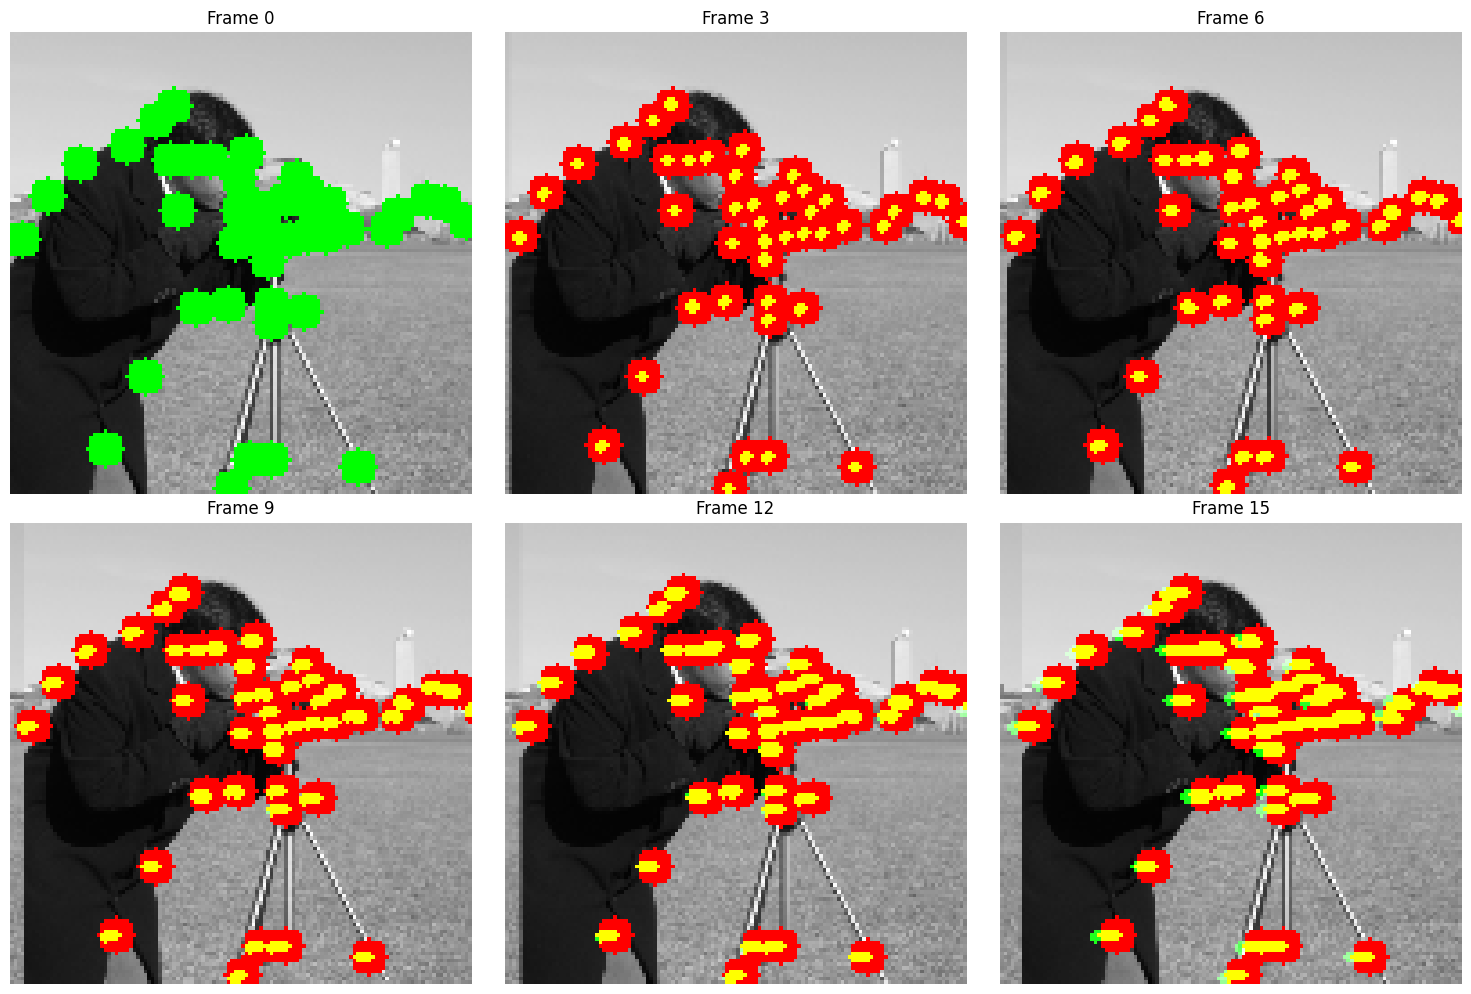

In [61]:
# Print status before visualization
print("\nDisplaying sample tracked frames:")

# Create a 2x3 grid of subplots (shows 6 sample frames)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Convert 2D axes array to 1D for easy indexing

# Show 6 evenly spaced frames (avoid overcrowding)
for plot_idx in range(6):
    # Calculate frame index (evenly spaced: 0, 3, 6, ..., up to last frame)
    frame_idx = min(plot_idx * 3, len(tracked_frames) - 1)
    
    # Convert BGR (OpenCV) to RGB (matplotlib) for correct color display
    frame_rgb = cv2.cvtColor(tracked_frames[frame_idx], cv2.COLOR_BGR2RGB)
    
    # Display frame on the subplot
    axes[plot_idx].imshow(frame_rgb)
    axes[plot_idx].set_title(f"Frame {frame_idx}")
    axes[plot_idx].axis('off')  # Hide axes (focus on tracks)

# Adjust spacing between subplots (avoids overlapping titles)
plt.tight_layout()
plt.show()

# <a id='toc8_'></a>[Step 7: Create and Display Animation](#toc0_)

- You need to install **<span style='Color:Red'>FFmpeg</span>**.
- Download the precompiled build from `ffmpeg.org`, 
- extract it, and add its bin folder to your `system` PATH.

In [62]:
# Clear any existing plots to prevent extra frame output
plt.close('all')

In [63]:
# Define animation update function
def update(frame):
    """Update function for animation - displays one frame at a time"""
    plt.cla()  # Clear the current axis to avoid frame overlap
    # Display current frame with proper color conversion
    plt.imshow(cv2.cvtColor(tracked_frames[frame], cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {frame} - Lucas-Kanade Optical Flow (Infinite Loop)")
    plt.axis('off')  # Hide axis
    return []  # Return empty list for blitting

In [64]:
# Create the animation
fig = plt.figure(figsize=(4, 3))
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=range(num_frames),  # Frames to animate through
    interval=100,  # Delay between frames in milliseconds (100ms = 10fps)
    blit=True,  # Optimize animation by only redrawing changed parts
    repeat=True  # Make animation loop infinitely
)

print("\nDisplaying infinite loop animation (only video, no extra frames):")
# Convert animation to HTML5 video for display in Jupyter
# This requires FFmpeg to be installed and in your system PATH
video_display = HTML(ani.to_html5_video())
display(video_display)

# Prevent additional plot rendering
plt.close(fig)


Displaying infinite loop animation (only video, no extra frames):
